# Validación de `loader.py`

Este notebook verifica que el pipeline de carga implementado en `loader.py` produce un dataset base correcto y completo.

**Prerrequisito**: haber ejecutado `01_exploration.ipynb` al menos una vez para generar los artefactos CCS en `data/interim/`.

## 1. Setup del entorno

El paquete `triaje_ia` está instalado en modo editable via `uv sync`. Se importan las funciones principales del loader y las rutas universales desde `triaje_ia.config`.

In [1]:
from triaje_ia.config import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS_DIR, FIGURES_DIR
from triaje_ia.data.loader import cargar_dataset_base
import pandas as pd

## 2. Carga del dataset base

Se ejecuta el pipeline completo: carga de tablas raw, cálculo de edad, agregación de medicación, mapeo ICD→CCS y construcción del label de disposition. Con `forzar=True` se regenera el caché aunque ya exista, garantizando que estamos viendo el resultado del código actual y no de una ejecución anterior.

In [2]:
df = cargar_dataset_base(forzar=True)
# forzar=True la primera vez para que genere el caché, las siguientes veces se puede quitar o dejarlo en False

2026-05-07 19:25:20.990 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:70 - EDSTAYS: 425,087 filas | 9 columnas
2026-05-07 19:25:21.544 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:70 - TRIAGE: 425,087 filas | 11 columnas
2026-05-07 19:25:25.727 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:70 - MEDRECON: 2,987,342 filas | 9 columnas
2026-05-07 19:25:25.863 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:86 - PATIENTS (MIMIC-IV core): 364,627 pacientes
2026-05-07 19:25:26.438 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:98 - DIAGNOSIS: 899,050 filas
2026-05-07 19:25:26.439 | INFO     | triaje_ia.data.loader:construir_dataset_base:266 - Construyendo dataset base...
2026-05-07 19:25:26.639 | INFO     | triaje_ia.data.loader:construir_dataset_base:276 - edstays INNER triage: 425,087 filas
2026-05-07 19:25:27.035 | INFO     | triaje_ia.data.loader:_calcular_edad:142 - Edad: mediana=53 | rango=[18, 103] | nulos=76
2026-05-07 19:26:34.448 | INFO     | triaje

### 2.1 Dimensiones y tipos de columna

Se verifica que el DataFrame tiene las dimensiones esperadas y que los tipos de dato son los correctos.

In [4]:
print(df.shape)        # (filas, columnas) — 
df.dtypes              # tipos de cada columna

(425087, 23)


subject_id                    int64
hadm_id                     float64
stay_id                       int64
intime               datetime64[ns]
outtime                      object
gender                       object
race                         object
arrival_transport            object
disposition                  object
temperature                 float64
heartrate                   float64
resprate                    float64
o2sat                       float64
sbp                         float64
dbp                         float64
pain                         object
acuity                      float64
chiefcomplaint               object
age                           Int64
n_medicamentos                int16
medicacion_raw               object
label_disposition              Int8
ccs_category                  Int16
dtype: object

### 2.2 Vista de las primeras filas

Inspección visual del dataset transpuesto para verificar que las columnas tienen valores coherentes. 

In [5]:
df.head(3).T           

,0,1,2
subject_id,10000032,10000032,10000032
hadm_id,22595853.0,22841357.0,25742920.0
stay_id,33258284,38112554,35968195
intime,2180-05-06 19:17:00,2180-06-26 15:54:00,2180-08-05 20:58:00
outtime,2180-05-06 23:30:00,2180-06-26 21:31:00,2180-08-06 01:44:00
gender,F,F,F
race,WHITE,WHITE,WHITE
arrival_transport,AMBULANCE,AMBULANCE,AMBULANCE
disposition,ADMITTED,ADMITTED,ADMITTED
temperature,98.4,98.9,99.4


### 2.3 Análisis de valores nulos

Se cuantifica el porcentaje de nulos por columna para identificar qué variables tienen datos faltantes.

In [6]:
nulos = df.isna().sum()
nulos_pct = (nulos / len(df) * 100).round(1)

resumen_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "pct": nulos_pct
}).query("n_nulos > 0").sort_values("pct", ascending=False)

resumen_nulos

,n_nulos,pct
hadm_id,222071,52.2
temperature,23415,5.5
resprate,20353,4.8
o2sat,20596,4.8
dbp,19091,4.5
sbp,18291,4.3
heartrate,17090,4.0
pain,12933,3.0
acuity,6987,1.6
ccs_category,1108,0.3


### 2.4 Distribución del target

Se verifica la distribución de la variable objetivo:
- **`acuity`** (1–5): se espera predominio del nivel 3 (~53%).


In [7]:
print("=== ACUITY ===")
print(df["acuity"].value_counts(dropna=False).sort_index())


=== ACUITY ===
acuity
1.0     24019
2.0    139411
3.0    225066
4.0     28504
5.0      1100
NaN      6987
Name: count, dtype: int64


## 3. Validación de `ccs_category`

La columna `ccs_category` unifica los diagnósticos ICD-9 e ICD-10 en una categoría CCS numérica (1–285). Se verifica que el mapeo se ha ejecutado correctamente y se consultan los nombres de las categorías más frecuentes usando los parquets CCS generados en `01_exploration.ipynb`.

In [9]:
from triaje_ia.data.loader import cargar_mappings_ccs

ccs_icd9, ccs_icd10 = cargar_mappings_ccs()

# El nombre canónico está en ICD-10 (descripciones más completas)
nombres_ccs = (
    ccs_icd10[["CCS CATEGORY", "CCS CATEGORY DESCRIPTION"]]
    .drop_duplicates("CCS CATEGORY")
    .rename(columns={"CCS CATEGORY": "ccs_category", 
                     "CCS CATEGORY DESCRIPTION": "ccs_nombre"})
)
nombres_ccs["ccs_category"] = pd.to_numeric(nombres_ccs["ccs_category"], errors="coerce")

# Ver el top 10 con nombre
top10 = (
    df["ccs_category"]
    .value_counts()
    .head(10)
    .reset_index()
    .merge(nombres_ccs, on="ccs_category", how="left")
)
print(top10.to_string(index=False))

 ccs_category  count                                                      ccs_nombre
          251  32056                                                  Abdominal pain
          102  24199                                          Nonspecific chest pain
          205  14809 Spondylosis; intervertebral disc disorders; other back problems
          259  11445                                    Residual codes; unclassified
          133  11212                                 Other lower respiratory disease
           84  10614                                    Headache; including migraine
          211  10342                                 Other connective tissue disease
          660  10187                                       Alcohol-related disorders
          244   9386            Other injuries and conditions due to external causes
          197   9191                         Skin and subcutaneous tissue infections


## 4. Validación de medicación previa

Se verifica que las columnas `n_medicamentos` y `medicacion_raw` se han generado correctamente. Los flags binarios `med_*` por clase farmacológica se calculan más adelante en `features.py` y se validan en el notebook 05.

In [10]:
print(f"n_medicamentos — describe:")
print(df["n_medicamentos"].describe().round(2))
print(f"\nPacientes con al menos 1 medicación previa: "
      f"{(df['n_medicamentos'] > 0).mean()*100:.1f}%")
print(f"\nEjemplo de medicacion_raw (primer paciente con medicación):")
print(df.loc[df['n_medicamentos'] > 0, 'medicacion_raw'].iloc[0][:200], '...')

n_medicamentos — describe:
count    425087.00
mean          6.00
std           6.71
min           0.00
25%           0.00
50%           4.00
75%          10.00
max          67.00
Name: n_medicamentos, dtype: float64

Pacientes con al menos 1 medicación previa: 72.3%

Ejemplo de medicacion_raw (primer paciente con medicación):
asthma/copd therapy - beta 2-adrenergic agents, inhaled, short acting, antiretroviral - nucleoside and nucleotide analog rtis combinations, vitamins - d derivatives, diuretic - loop, asthma/copd - ant ...


### 4.1 Análisis de `n_medicamentos`

Se analiza la distribución del número de medicamentos previos por visita para detectar posibles anomalías. En particular, se investigan los casos con un número extremadamente alto de medicamentos

In [11]:
print(df["n_medicamentos"].describe())
print(f"\nSin medicación registrada: {df['n_medicamentos'].isna().sum():,}")
# Los NaN aquí son stays que directamente no aparecen en medrecon (LEFT JOIN)

count    425087.000000
mean          6.004350
std           6.705543
min           0.000000
25%           0.000000
50%           4.000000
75%          10.000000
max          67.000000
Name: n_medicamentos, dtype: float64

Sin medicación registrada: 0


In [12]:
print(df["n_medicamentos"].max())
df.nlargest(5, "n_medicamentos")[["stay_id", "age", "n_medicamentos"]].T

67


,365354,23115,23130,23113,365353
stay_id,34395897,30808521,36988087,30620517,37825252
age,61,83,83,82,61
n_medicamentos,67,63,63,57,57


In [13]:
df[df["n_medicamentos"] == 67].T

,365354
subject_id,18592426
hadm_id,29832710.0
stay_id,34395897
intime,2186-04-22 09:49:00
outtime,2186-04-22 17:07:00
gender,M
race,WHITE
arrival_transport,WALK IN
disposition,ADMITTED
temperature,98.6


In [14]:
df.nlargest(10, "n_medicamentos")[["stay_id", "subject_id", "age", "gender", "acuity", "n_medicamentos", "medicacion_raw"]].T

,365354,23115,23130,23113,365353,23131,126772,233830,363988,363995
stay_id,34395897,30808521,36988087,30620517,37825252,39347674,32963238,35867442,39075599,33349490
subject_id,18592426,10561909,10561909,10561909,18592426,10561909,13009233,15497609,18561128,18561128
age,61,83,83,82,61,82,61,69,48,47
gender,M,F,F,F,M,F,F,F,F,F
acuity,2.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0
n_medicamentos,67,63,63,57,57,56,55,55,54,54
medicacion_raw,medical supplies and dme - blood glucose tests...,"analgesic or antipyretic non-opioid, asthma/co...","analgesic or antipyretic non-opioid, asthma/co...","analgesic or antipyretic non-opioid, otic (ear...",medical supplies and dme - blood glucose tests...,"analgesic or antipyretic non-opioid, otic (ear...","analgesic or antipyretic non-opioid, asthma/co...","analgesic or antipyretic non-opioid, analgesic...","analgesic or antipyretic non-opioid, asthma/co...","analgesic or antipyretic non-opioid, asthma/co..."


In [15]:
caso = df[df["n_medicamentos"] == 67].iloc[0]
print(caso["medicacion_raw"])

medical supplies and dme - blood glucose tests, androgen - single agents, nasal antihistamines, vitamins - d derivatives, minerals and electrolytes - calcium replacement/vitamin d combinations, antiseptic - biguanides, dermatological - antifungal hydroxypyridinone, antihistamines - 2nd generation, acne therapy topical - anti-infective, alternative therapy - unclassified, digestive enzyme mixtures, antihyperlipidemic - hmg coa reductase inhibitors (statins), cns stimulant - amphetamine combinations, digitalis glycosides, antidepressant - serotonin-norepinephrine reuptake inhibitors (snris), antiretroviral - nucleoside reverse transcriptase inhibitors (nrti), ophthalmic antibiotic - macrolides, vitamins - b preparation combinations, immune globulin - gamma globulin (igg), human, insulin response enhancers - biguanides, insulin analogs - rapid acting, human insulins - intermediate acting, diuretic - thiazides and related, dermatological - antibacterial other, nasal corticosteroids, granul

## 5. Resumen visual del dataset base

Panel de 6 gráficos que ofrece una radiografía completa del dataset en el minuto 0: distribución de los targets (acuity y disposition), demografía (edad), constantes vitales, valores nulos y número de medicaciones previas. Esta figura resume de forma compacta todo lo que el modelo tiene disponible en el momento del triaje.

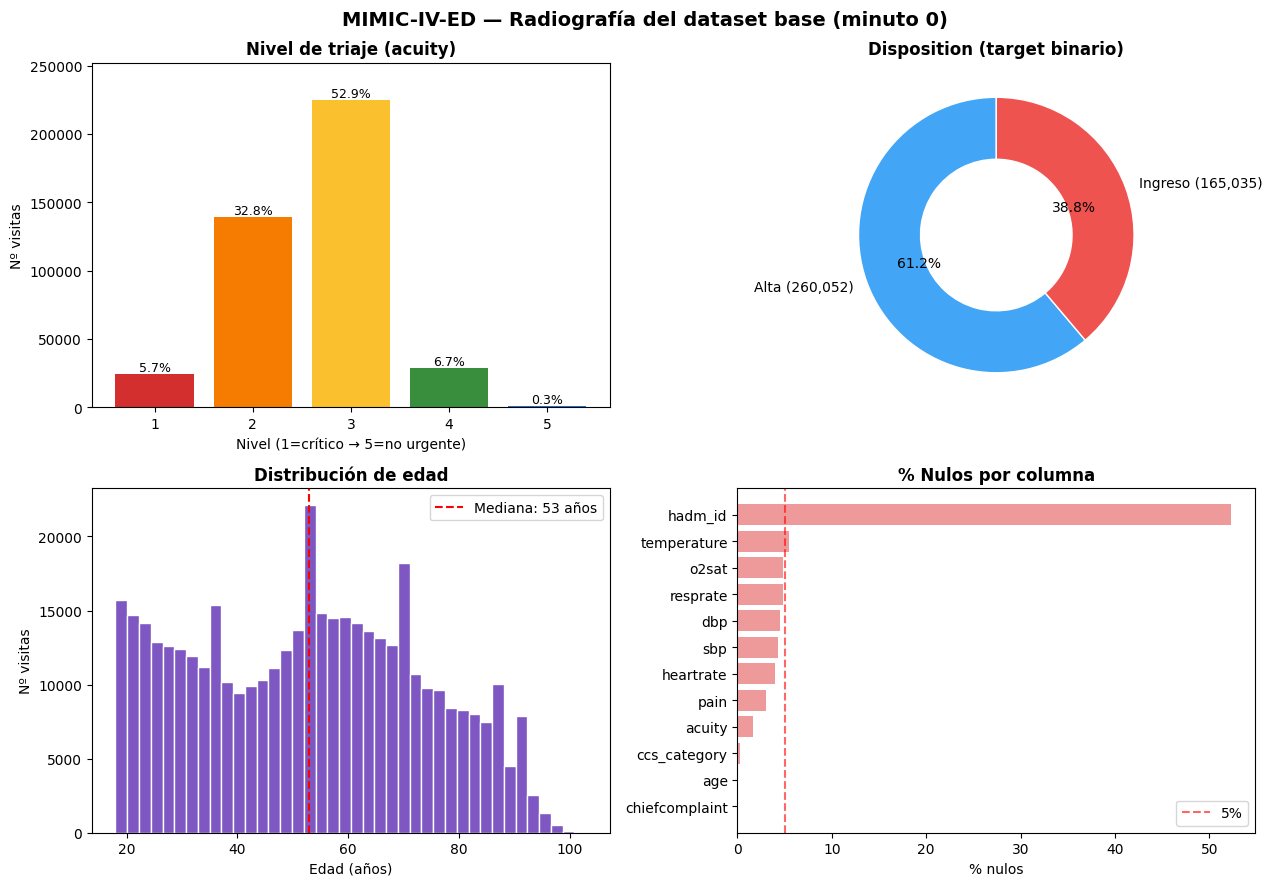

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("MIMIC-IV-ED — Radiografía del dataset base (minuto 0)",
             fontsize=14, fontweight="bold")

# 1. Distribución de acuity
ax = axes[0, 0]
acuity_counts = df["acuity"].value_counts().sort_index()
bars = ax.bar(acuity_counts.index.astype(int).astype(str), acuity_counts.values,
              color=["#d32f2f", "#f57c00", "#fbc02d", "#388e3c", "#1976d2"])
ax.set_title("Nivel de triaje (acuity)", fontweight="bold")
ax.set_xlabel("Nivel (1=crítico → 5=no urgente)")
ax.set_ylabel("Nº visitas")
for bar, val in zip(bars, acuity_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val / len(df) * 100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.margins(y=0.12)

# 2. Disposition (target binario)
ax = axes[0, 1]
disp_counts = df["label_disposition"].value_counts().sort_index()
ax.pie(disp_counts.values,
       labels=[f"Alta ({disp_counts[0]:,})", f"Ingreso ({disp_counts[1]:,})"],
       autopct="%1.1f%%", colors=["#42a5f5", "#ef5350"],
       startangle=90, wedgeprops=dict(width=0.45, edgecolor="white"))
ax.set_title("Disposition (target binario)", fontweight="bold")

# 3. Distribución de edad
ax = axes[1, 0]
ax.hist(df["age"].dropna(), bins=40, color="#7e57c2", edgecolor="white")
ax.axvline(df["age"].median(), color="red", linestyle="--",
           label=f"Mediana: {df['age'].median():.0f} años")
ax.set_title("Distribución de edad", fontweight="bold")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Nº visitas")
ax.legend()

# 4. % Nulos por columna (sólo columnas con nulos)
ax = axes[1, 1]
nulos_pct = (df.isna().sum() / len(df) * 100)
nulos_pct = nulos_pct[nulos_pct > 0].sort_values()
ax.barh(nulos_pct.index, nulos_pct.values, color="#ef9a9a")
ax.axvline(5, color="red", linestyle="--", alpha=0.6, label="5%")
ax.set_title("% Nulos por columna", fontweight="bold")
ax.set_xlabel("% nulos")
ax.legend()

fig.tight_layout()
plt.show()

## 6. Caso de ejemplo: paciente típico de urgencias

Para verificar que el dataset es internamente coherente, se extrae un paciente representativo (acuity 3, entre 50 y 60 años, 5–10 medicamentos previos, ingresado) y se imprime su perfil completo. Esto permite comprobar visualmente que todas las columnas tienen valores con sentido clínico para un mismo paciente.

In [17]:
ejemplo = df[
    (df["acuity"] == 3) &
    (df["age"].between(50, 60)) &
    (df["n_medicamentos"].between(5, 10)) &
    (df["label_disposition"] == 1)
].iloc[0]

cols_fijas = [
    "stay_id", "subject_id",
    "age", "gender", "race", "arrival_transport",
    "chiefcomplaint", "intime",
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain",
    "acuity", "label_disposition", "disposition",
    "n_medicamentos", "medicacion_raw"
]

print("=" * 45)
print("EJEMPLO: paciente típico de urgencias")
print("=" * 45)

for col in cols_fijas:
    val = ejemplo[col]
    if pd.notna(val) and val != "":
        print(f"  {col:<25} {val}")

EJEMPLO: paciente típico de urgencias
  stay_id                   33258284
  subject_id                10000032
  age                       52
  gender                    F
  race                      WHITE
  arrival_transport         AMBULANCE
  chiefcomplaint            Abd pain, Abdominal distention
  intime                    2180-05-06 19:17:00
  temperature               98.4
  heartrate                 70.0
  resprate                  16.0
  o2sat                     97.0
  sbp                       106.0
  dbp                       63.0
  pain                      0
  acuity                    3.0
  label_disposition         1
  disposition               ADMITTED
  n_medicamentos            9
  medicacion_raw            asthma/copd therapy - beta 2-adrenergic agents, inhaled, short acting, antiretroviral - nucleoside and nucleotide analog rtis combinations, vitamins - d derivatives, diuretic - loop, asthma/copd - anticholinergic agents, inhaled short acting, smoking deterrents 

## 7. Análisis de visitas repetidas por paciente

MIMIC-IV-ED incluye pacientes con múltiples visitas a urgencias a lo largo del tiempo. Se analiza la distribución del número de visitas por paciente para cuantificar este fenómeno, que tiene implicaciones para la validación del modelo: si un mismo paciente aparece en train y test, podría haber data leakage por similitud de perfil clínico.

In [18]:
import pandas as pd

edstays = pd.read_csv(r"C:\Users\CARLOS\triaje-ia-tfg\data\raw\edstays.csv.gz", low_memory=False)

visitas_por_paciente = edstays.groupby("subject_id")["stay_id"].count()

print(visitas_por_paciente.value_counts().sort_index().head(20))
print(f"\nTotal pacientes:         {visitas_por_paciente.shape[0]:,}")
print(f"Con más de 1 visita:     {(visitas_por_paciente > 1).sum():,}")
print(f"Con más de 2 visitas:    {(visitas_por_paciente > 2).sum():,}")
print(f"Mediana visitas:         {visitas_por_paciente.median():.0f}")
print(f"Máximo visitas:          {visitas_por_paciente.max()}")

stay_id
1     135552
2      32672
3      13700
4       7377
5       4375
6       2822
7       2011
8       1416
9       1063
10       802
11       590
12       486
13       415
14       269
15       255
16       210
17       182
18       139
19       120
20       108
Name: count, dtype: int64

Total pacientes:         205,504
Con más de 1 visita:     69,952
Con más de 2 visitas:    37,280
Mediana visitas:         1
Máximo visitas:          321
